# Load CSV and create a time index (UTC)

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/smard_pv_realized_quarterhour_2015-2026.csv")

df["time"] = pd.to_datetime(
    df["timestamp_ms"], unit="ms", utc=True
)  # Convert Unix timestamps to UTC
df = df.set_index("time")  # Set the index to the date/time
df = df.drop(columns="timestamp_ms")

# A brief exploratory analysis of the data
df.head()
print("NaN-Werte:", df["pv_mwh"].isna().sum())
print(df.index.min(), df.index.max())
print("Duplikate:", df.index.duplicated().sum())
print("Zeilen:", len(df))

NaN-Werte: 610
2014-12-28 23:00:00+00:00 2026-06-21 21:45:00+00:00
Duplikate: 0
Zeilen: 402524


# NaN analysis (to be trimmed later)

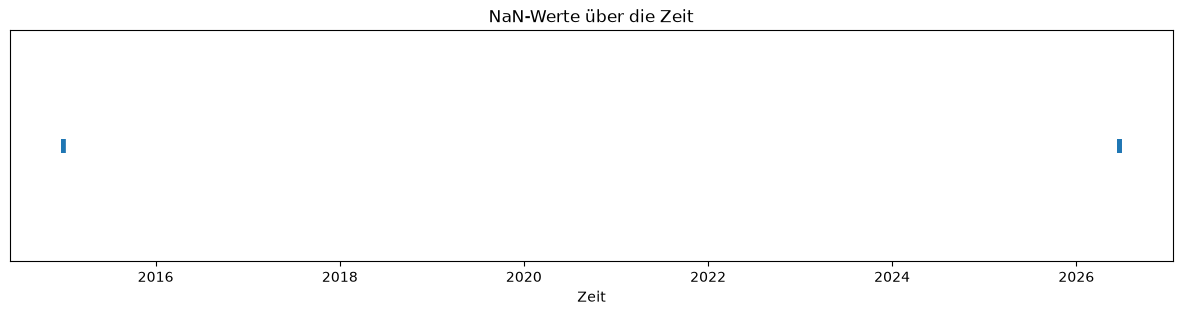

In [2]:
import matplotlib.pyplot as plt

mask = df["pv_mwh"].isna()

# Plot when NaN values occurred -> shows only the start date of the recording
# and the end date when I retrieved the data
plt.figure(figsize=(15, 3))
plt.scatter(
    df.index[mask],
    [1] * mask.sum(),
    marker="|",
    s=100,
)
plt.yticks([])
plt.xlabel("Zeit")
plt.title("NaN-Werte über die Zeit")
plt.show()

In [3]:
valid = df.dropna()

print("Erster gültiger Wert:", valid.index.min())
print("Letzter gültiger Wert:", valid.index.max())

Erster gültiger Wert: 2014-12-31 23:00:00+00:00
Letzter gültiger Wert: 2026-06-18 13:15:00+00:00


# Aggregation to hourly (Quaerterhour → Hour)

In [4]:
# Energy values (MWh) are summed; incomplete hours are set to NaN via min_count=4
n_quarterhours = len(df)
df = df["pv_mwh"].resample("h").sum(min_count=4).to_frame()

print("Viertelstunden:", n_quarterhours, "-> Stunden:", len(df))
print("Unvollständige Stunden (NaN):", df["pv_mwh"].isna().sum())

Viertelstunden: 402524 -> Stunden: 100631
Unvollständige Stunden (NaN): 153


# Validation against SMARD's native hourly series

In [5]:
# Load SMARD's own hourly series and compare on the shared index.
smard_hour = pd.read_csv("../data/raw/smard_pv_realized_hour_2015-2026.csv")
smard_hour["time"] = pd.to_datetime(smard_hour["timestamp_ms"], unit="ms", utc=True)
smard_hour = smard_hour.set_index("time")["pv_mwh"]

both = pd.concat(
    [df["pv_mwh"].rename("self"), smard_hour.rename("smard")], axis=1
).dropna()
max_diff = (both["self"] - both["smard"]).abs().max()

print("Verglichene Stunden:", len(both))
print("Maximale Abweichung [MWh]:", round(max_diff, 4))
print("Relativ zum Maximalwert:", f"{max_diff / both['smard'].max():.1e}")

Verglichene Stunden: 100478
Maximale Abweichung [MWh]: 0.02
Relativ zum Maximalwert: 3.6e-07


# Set start and end dates

In [6]:
# Available of full 11 years
start = pd.Timestamp("2014-12-31 23:00", tz="UTC")
end = pd.Timestamp("2025-12-31 23:00", tz="UTC")
df = df.loc[start:end]

In [7]:
print("NaN nach dem Schnitt:", df["pv_mwh"].isna().sum())

NaN nach dem Schnitt: 0


# Distribution of small values

In [8]:
# Check if there are any remaining zero values
print(df["pv_mwh"].describe())
print("\nWerte unter 1 MWh:", (df["pv_mwh"] < 1).sum())
print("Exakte Nullen:", (df["pv_mwh"] == 0).sum())
print("Negative Werte:", (df["pv_mwh"] < 0).sum())

count    96433.000000
mean      5481.886680
std       8719.514057
min          0.000000
25%          0.840000
50%        160.360000
75%       8452.590000
max      52132.250000
Name: pv_mwh, dtype: float64

Werte unter 1 MWh: 24326
Exakte Nullen: 7770
Negative Werte: 0


In [9]:
zeros = df[df["pv_mwh"] == 0]

# At what UTC hour do the exact zeros occur?
print(zeros.index.hour.value_counts().sort_index())

# Is the maximum value real?
print(df["pv_mwh"].idxmax(), df["pv_mwh"].max())

time
0     830
1     793
2     635
3     459
4     308
5     204
6      26
16     31
17    238
18    385
19    541
20    751
21    859
22    868
23    842
Name: count, dtype: int64
2025-06-20 10:00:00+00:00 52132.25


<Axes: title={'center': 'Tagesgang 04.09.2025'}, xlabel='time'>

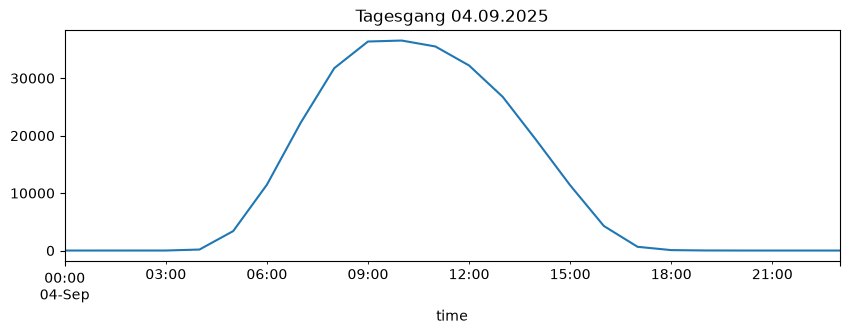

In [10]:
# Plotting a random date (my birthday, lol)
df.loc["2025-09-04", "pv_mwh"].plot(figsize=(10, 3), title="Tagesgang 04.09.2025")

# Local time & DST handling

In [11]:
# UTC avoids DST; local hour used for features only
hour_local = df.index.tz_convert("Europe/Berlin").hour
print("Duplikate im UTC-Index:", df.index.duplicated().sum())
print("Lokale Stunde (erste 3):", hour_local[:3].tolist())

Duplikate im UTC-Index: 0
Lokale Stunde (erste 3): [0, 1, 2]


# Finalize: gap check & regular grid

In [12]:
# heck time grid completeness first, then value completeness
full = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing = full.difference(df.index)
print("Fehlende Stunden im Raster:", len(missing))
assert missing.empty, f"Lücken im Stundenraster: {missing.tolist()}"

df = df.reindex(full)
df.index.name = "time"

assert df["pv_mwh"].notna().all(), "NaN in der Stundenreihe"
print("Index-Frequenz:", df.index.freq)

Fehlende Stunden im Raster: 0
Index-Frequenz: <Hour>


# Save the cleaned-up table

In [13]:
from pvforecast.config import PROCESSED_DIR

# Save the processed file as parquet
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_parquet(PROCESSED_DIR / "pv_hourly.parquet")

check = pd.read_parquet(PROCESSED_DIR / "pv_hourly.parquet")
print(check.index.dtype)
print(check.shape)
print(check.columns.tolist())

datetime64[ms, UTC]
(96433, 1)
['pv_mwh']
